# Survivorship Bias Detection and Quantification

**Docker image**: `ml4t`

## Purpose

`01_us_equities_eda` ended on an anomaly: the **US equities panel** records 777 symbols
leaving it, and every single one leaves in 2014 or later. This notebook picks that up and
asks the question a backtest actually depends on:

> For the window where the panel *does* record exits, how much does a portfolio that
> silently drops the leavers overstate its return?

Answering it takes three steps, and the middle one is where the work is:

1. **Read the exit record** and establish what the panel does and does not know about
   the symbols that left.
2. **Repair the return series.** The adjusted prices contain unadjusted corporate actions.
   Left uncorrected they do not merely add noise — they reverse the sign of the answer.
3. **Quantify the bias**, modelling the one quantity the panel cannot observe: what a holder
   received *after* the last quote.

## Learning objectives

- Separate symbols that left the panel from symbols that survived to its final date.
- Distinguish what a price panel observes (a path to a last quote) from what a delisting
  study needs (a terminal outcome), and reason about why the gap forces a modelling step.
- Detect unadjusted splits and reorganisations by their return signature, and see how a
  handful of bad rows propagates into a headline number.
- Build CRSP-calibrated delisting scenarios and put a percentile band around the bias.
- Distinguish *survivorship* completeness from *universe* completeness.

## Book reference

Chapter 2, §2.3 (data-quality framework — survivorship bias).

## Prerequisites

- US equities parquet under `ML4T_DATA_PATH`; loader `data.load_us_equities`.
- Read `01_us_equities_eda` first.

In [1]:
"""Survivorship Bias Detection — quantifying bias in the US equities panel."""

import pickle
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

from data import load_us_equities
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI. The Monte Carlo bias
# estimates cited in chapter §2.3 are anchored to SEED=42; overriding the seed
# will shift the reported numbers.
SEED = 42
N_SIMS = 1000  # Monte Carlo draws per scenario

# Analysis window. The panel records no exit before 2014 (see §1), so a window that
# opens earlier spends its first years measuring a delisting rate that is zero by
# construction. 2014-01-01 to the panel's final date is the only span over which the
# panel behaves like a live universe.
ANALYSIS_START = "2014-01-01"

# A daily return is not trusted when it exceeds +100% (a long position cannot lose more
# than 100%, so the rule is one-sided) or when it is computed off a prior session that
# printed zero volume (a stale quote). See §3.
MAX_TRUSTED_RETURN = 1.0
MIN_SESSION_COVERAGE = 0.2  # a session must quote this share of the universe to count

In [3]:
set_global_seeds(SEED)

# Colors used by every chart below, so no plotting cell defines its own.
PALETTE = {
    "survivors": COLORS["copper"],  # the biased portfolio — the wrong answer
    "universe": COLORS["blue"],  # the full universe — the reference
    "bull": COLORS["slate"],
    "stress": COLORS["neutral"],
    "gap": COLORS["amber_light"],
    "rule": COLORS["neutral"],
}

## 1. The exit record

A symbol has *left* the panel if its last observation predates the panel's final date.
Everything else is still quoted when the feed stops.

In [4]:
wiki = load_us_equities()

print(f"Panel shape: {wiki.shape}")
print(f"Date range: {wiki['timestamp'].min()} to {wiki['timestamp'].max()}")
print(f"Unique symbols: {wiki['symbol'].n_unique():,}")

Panel shape: (15389314, 14)
Date range: 1962-01-02 to 2018-03-27
Unique symbols: 3,199


In [5]:
dataset_end = wiki["timestamp"].max()

lifespans = (
    wiki.group_by("symbol")
    .agg(
        [
            pl.col("timestamp").min().alias("first_date"),
            pl.col("timestamp").max().alias("last_date"),
            pl.len().alias("trading_days"),
        ]
    )
    .with_columns((pl.col("last_date") < dataset_end).alias("has_left"))
)

n_total = lifespans.height
n_left = lifespans.filter(pl.col("has_left")).height
n_survived = n_total - n_left

print(f"Panel final date: {dataset_end}")
print(f"Total symbols:    {n_total:,}")
print(f"Still quoted:     {n_survived:,} ({n_survived / n_total:.1%})")
print(f"Left the panel:   {n_left:,} ({n_left / n_total:.1%})")

Panel final date: 2018-03-27
Total symbols:    3,199
Still quoted:     2,422 (75.7%)
Left the panel:   777 (24.3%)


In [6]:
exits_by_year = (
    lifespans.filter(pl.col("has_left"))
    .with_columns(pl.col("last_date").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.len().alias("exits"))
    .sort("year")
)
exits_by_year

year,exits
i32,u32
2014,102
2015,194
2016,216
2017,193
2018,72


### The exit record starts abruptly

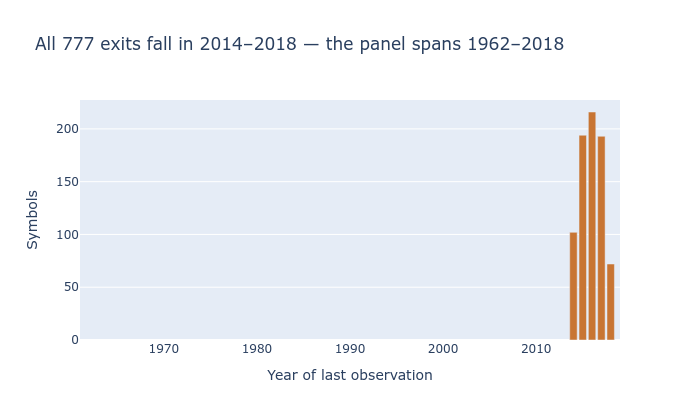

In [7]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=exits_by_year["year"].to_list(),
        y=exits_by_year["exits"].to_list(),
        marker_color=PALETTE["survivors"],
        name="Symbols leaving the panel",
    )
)
fig.update_layout(
    title=(
        f"All {n_left:,} exits fall in {exits_by_year['year'].min()}–{exits_by_year['year'].max()} "
        f"— the panel spans {lifespans['first_date'].min().year}–{dataset_end.year}"
    ),
    xaxis_title="Year of last observation",
    yaxis_title="Symbols",
    xaxis=dict(range=[lifespans["first_date"].min().year - 1, dataset_end.year + 1]),
    height=420,
    showlegend=False,
)
fig.show()

### Reading the chart

The bars occupy the last four years of a fifty-six-year panel. The rest of the axis is empty.

That is not a claim about the equity market. Firms were acquired, went private and went
bankrupt throughout the panel's history — Enron was delisted from the NYSE in January 2002,
and it is not in this file's exit record because it is not in this file at all. The chart is a
claim about **the data collection process**: exit information was not being captured, and then
around 2014 it started being captured.

The mechanism is the panel's provenance. It was assembled from the community-maintained
Quandl WIKI feed: the symbols that existed when the project ran, each backfilled to its own
IPO. Symbols that had already died were never added, so their departure was never recorded.
Once the feed was live, symbols leaving it *were* recorded. Then contributor interest decayed,
and in March 2018 the feed stopped.

This is the tax on free public data, and it has a precise consequence: **for the pre-2014 era
the panel cannot tell us what we are missing.** Not "the bias is small" — unknown. The only
window over which the panel behaves like a live universe is 2014 to the final date, so that
is the window this notebook measures.

## 2. What the panel cannot tell us

Suppose we know exactly which symbols left. Why model their outcomes at all — why not just
read off what happened to them?

Because the panel does not contain it. Fourteen columns: `symbol`, `timestamp`, raw OHLCV,
`ex-dividend`, `split_ratio`, and the five `adj_*` prices. Nothing else.

| What we need | Where it lives | In this panel? |
|---|---|---|
| The price path while the symbol traded | `adj_close` | Yes |
| *Why* the symbol stopped trading | CRSP `DLSTCD` (delisting code) | **No** |
| What a holder received *after* the last quote | CRSP `DLRET` (delisting return) | **No** |

A last quote is not a terminal value. When a firm is acquired, holders are paid the deal
consideration after the tape goes quiet. When a firm is liquidated, holders receive a
residual, often near zero, sometimes months later. Neither payment appears in a price file.

It is worse than a missing column. The panel does not even reliably observe the *date* of the
exit. Symbols in §3 sit at stale quotes on zero volume for days before they vanish, and the
feed's coverage was decaying the entire time. A symbol disappearing from this file can mean
"acquired", "liquidated", or "the contributors stopped updating it".

So the terminal return is **unobservable here, and must be modelled**. §4 builds three
scenarios from published CRSP outcome rates. This is a real cost of the free panel, not a
stylistic choice: with CRSP the terminal return is a column, and §4 through §6 collapse into
a `join`.

## 3. The adjusted prices are not clean

Before measuring anything, one check. The bias is a difference between two compounded return
series, so a single bad daily return propagates into the headline. Look for returns the
market cannot produce.

A long position cannot lose more than 100% in a day, so the test is one-sided: a daily gain
above +100% is either a genuinely extraordinary event or an unadjusted corporate action.

In [8]:
window_start = date.fromisoformat(ANALYSIS_START)
window_end = dataset_end  # loader returns a `date`

panel = wiki.filter(
    (pl.col("timestamp").dt.date() >= window_start) & (pl.col("timestamp").dt.date() <= window_end)
)

# Universe = symbols quoted within the first month of the window.
first_month = window_start + timedelta(days=30)
universe = (
    panel.group_by("symbol")
    .agg(pl.col("timestamp").min().alias("first_date"))
    .filter(pl.col("first_date").dt.date() <= first_month)["symbol"]
    .to_list()
)
panel = panel.filter(pl.col("symbol").is_in(universe))

returns = (
    panel.sort(["symbol", "timestamp"])
    .with_columns(
        [
            (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias("ret"),
            pl.col("volume").shift(1).over("symbol").alias("prev_volume"),
        ]
    )
    .drop_nulls("ret")
)

print(f"Window: {window_start} to {window_end}")
print(f"Universe at start: {len(universe):,} symbols, {len(returns):,} daily returns")

Window: 2014-01-01 to 2018-03-27
Universe at start: 3,095 symbols, 2,931,079 daily returns


In [9]:
# The largest daily gains in the window, with the corporate-action inputs alongside.
returns.sort("ret", descending=True).head(6).select(
    ["symbol", "timestamp", "close", "adj_close", "split_ratio", "prev_volume", "ret"]
)

symbol,timestamp,close,adj_close,split_ratio,prev_volume,ret
str,date,f64,f64,f64,f64,f64
"""HERO""",2015-11-09,14.2,14.2,1.0,0.0,283.0
"""EXXI""",2017-02-28,32.5,32.5,1.0,0.0,249.0
"""GDP""",2017-04-11,16.1,16.1,1.0,0.0,102.803997
"""PCO""",2017-12-05,660.0,660.0,1.0,97970.0,93.691535
"""BCEI""",2017-05-01,39.2,39.2,1.0,1.1747559e7,76.623762
"""NES""",2017-10-12,15.12,15.12,1.0,142659.0,57.513932


Every one of these is a corporate action the adjustment missed, and `split_ratio` reports
`1.0` for all of them:

- **HERO** (Hercules Offshore) emerged from Chapter 11 on 2015-11-06. The old equity was
  cancelled and new shares were issued on the same ticker. `$0.05 → $14.20` is not a return;
  it is two different securities. Note the zero volume on the days before — those `$0.05`
  quotes are stale.
- **PCO** (Pendrell) ran a 1-for-100 reverse split on 2017-12-05. `$6.97 → $660.00`, and the
  `split_ratio` column never fired.
- **EXXI** (Energy XXI) relisted post-bankruptcy on the same ticker.

Two rules follow directly, and both are diagnostic rather than cosmetic — they say
*"we cannot compute a return across this event"*, and drop it, rather than shrinking it
toward something plausible:

1. A daily return above **+100%** is not trusted.
2. A daily return computed off a prior session that printed **zero volume** is not trusted
   — the denominator is a stale quote.

Both fire on observable evidence, and neither touches genuine crashes. GT Advanced
Technologies fell 92.8% on 2014-10-06 when it filed for Chapter 11, on 7.2M shares of real
volume. That is a return, and it survives both rules.

In [10]:
returns = returns.with_columns(
    ((pl.col("ret") > MAX_TRUSTED_RETURN) | (pl.col("prev_volume") == 0)).alias("suspect")
)

n_suspect = returns.filter(pl.col("suspect")).height
n_suspect_symbols = returns.filter(pl.col("suspect"))["symbol"].n_unique()
print(f"Untrusted returns: {n_suspect:,} of {len(returns):,} ({n_suspect / len(returns):.4%})")
print(f"Symbols affected:  {n_suspect_symbols} of {len(universe):,}")

gtat = returns.filter((pl.col("symbol") == "GTAT") & (pl.col("ret") < -0.9))
print("\nControl — GTAT's Chapter 11 filing, a real crash:")
print(gtat.select(["symbol", "timestamp", "ret", "prev_volume", "suspect"]))

Untrusted returns: 805 of 2,931,079 (0.0275%)
Symbols affected:  136 of 3,095

Control — GTAT's Chapter 11 filing, a real crash:
shape: (1, 5)
┌────────┬────────────┬───────────┬─────────────┬─────────┐
│ symbol ┆ timestamp  ┆ ret       ┆ prev_volume ┆ suspect │
│ ---    ┆ ---        ┆ ---       ┆ ---         ┆ ---     │
│ str    ┆ date       ┆ f64       ┆ f64         ┆ bool    │
╞════════╪════════════╪═══════════╪═════════════╪═════════╡
│ GTAT   ┆ 2014-10-06 ┆ -0.927602 ┆ 7.225635e6  ┆ false   │
└────────┴────────────┴───────────┴─────────────┴─────────┘


### Phantom sessions

One more artifact, on the calendar rather than the prices. A handful of symbols — LFVN and END
above all — print quotes on days the US market was closed. A session that only a sliver of the
universe trades on is not a session, and its cross-sectional mean is not a portfolio return.

In [11]:
session_coverage = returns.group_by("timestamp").agg(pl.len().alias("quoted")).sort("timestamp")
real_sessions = session_coverage.filter(pl.col("quoted") >= MIN_SESSION_COVERAGE * len(universe))
phantom = session_coverage.filter(pl.col("quoted") < MIN_SESSION_COVERAGE * len(universe))

print(f"Sessions kept:    {real_sessions.height:,}")
print(
    f"Phantom sessions: {phantom.height} (fewer than {MIN_SESSION_COVERAGE:.0%} of the universe quoted)"
)
phantom

Sessions kept:    1,064
Phantom sessions: 8 (fewer than 20% of the universe quoted)


timestamp,quoted
date,u32
2014-01-02,1
2014-01-20,3
2014-02-17,2
2014-04-18,2
2014-05-26,2
2014-07-04,2
2014-09-01,2
2017-04-14,9


Six of these are US market holidays — Martin Luther King Jr. Day, Presidents' Day, Good Friday,
Memorial Day, Independence Day, Labor Day — and 2017-04-14 is Good Friday again. The panel had
no business quoting any of them.

`2014-01-02` is different, and it is a nice illustration of how one bad row breeds another. That
session was genuinely open. It looks empty because a *return* needs a prior quote, and the only
symbol with a 2014-01-01 quote to difference against is LFVN — which printed on New Year's Day.
The rule catches it anyway, which is what a rule keyed to evidence rather than to a holiday
calendar is for.

In [12]:
returns = returns.filter(pl.col("timestamp").is_in(real_sessions["timestamp"].to_list()))

## 4. Delisting outcome scenarios

The terminal return — what a holder received after the last quote — is unobservable here
(§2), so we model the *mix* of outcomes rather than any individual one.

Each scenario specifies how the leavers split across three exit types, and what a holder
earns in each. The shares come from CRSP tabulations; the returns from the delisting-return
literature.

**Sources**

- Eckbo & Lithell (2025), *Merger-Driven Listing Dynamics*, JFQA — Table A1 Panel B,
  2,805 CRSP delistings, 2010–2020.
- Doidge, Karolyi & Stulz (2017), *Are There Too Few Publicly Listed Firms?*
- Shumway (1997) and Beaver, McNichols & Price (2007) on delisting returns.

**The load-bearing fact**: M&A dominates US delistings (~65%); outright bankruptcy is under
1%. "Cause" delistings are mostly compliance failures — low price, late filings.

**A caveat we carry forward.** These terminal returns are applied *on the delisting date*.
For acquisitions that is generous: deal premiums accrue as rumours circulate and the price
converges toward the offer, so by the last quote most of the +25% is already in the observed
path. Applying it again at exit double-counts. §6 measures how much this assumption is worth.

In [13]:
SCENARIOS = {
    "Empirical 2010-2020": {
        "description": "CRSP empirical rates (Eckbo & Lithell 2025)",
        "cause_share": 0.257,  # compliance / performance failures
        "acquisition_share": 0.655,  # M&A, including going-private deals
        "other_share": 0.088,  # voluntary + unknown
        "cause_return": -0.60,  # compliance failures: stock already depressed
        "acquisition_return": 0.25,  # typical M&A premium
        "other_return": 0.0,  # exit at market
    },
    "Bull Market": {
        "description": "High M&A activity (2014-2018 pattern)",
        "cause_share": 0.18,
        "acquisition_share": 0.73,  # peak M&A share (2018)
        "other_share": 0.09,
        "cause_return": -0.50,
        "acquisition_return": 0.30,  # higher premiums under competitive bidding
        "other_return": 0.0,
    },
    "Stress Period": {
        "description": "Higher distress (2010, 2020 pattern)",
        "cause_share": 0.32,
        "acquisition_share": 0.53,  # reduced M&A
        "other_share": 0.15,
        "cause_return": -0.80,
        "acquisition_return": 0.15,
        "other_return": -0.10,
    },
}

OUTCOMES = ["cause", "acquisition", "other"]
OUTCOME_LABELS = {
    "cause": "Cause (compliance)",
    "acquisition": "Acquisition (M&A)",
    "other": "Other (voluntary)",
}


def expected_terminal(params: dict) -> float:
    """Share-weighted terminal return for one scenario."""
    return sum(params[f"{o}_share"] * params[f"{o}_return"] for o in OUTCOMES)


scenario_table = pl.DataFrame(
    [
        {
            "scenario": name,
            **{f"{o}_share": p[f"{o}_share"] for o in OUTCOMES},
            **{f"{o}_return": p[f"{o}_return"] for o in OUTCOMES},
            "expected_terminal": round(expected_terminal(p), 4),
        }
        for name, p in SCENARIOS.items()
    ]
)
scenario_table

scenario,cause_share,acquisition_share,other_share,cause_return,acquisition_return,other_return,expected_terminal
str,f64,f64,f64,f64,f64,f64,f64
"""Empirical 2010-2020""",0.257,0.655,0.088,-0.6,0.25,0.0,0.0096
"""Bull Market""",0.18,0.73,0.09,-0.5,0.3,0.0,0.129
"""Stress Period""",0.32,0.53,0.15,-0.8,0.15,-0.1,-0.1915


The two panels below are the whole scenario definition: who leaves how, and what a holder
earns when they do. The expected terminal return in the right-hand panel is the
share-weighted average — and note it is *positive* in two of three scenarios, because
acquisitions dominate and acquisitions pay a premium.

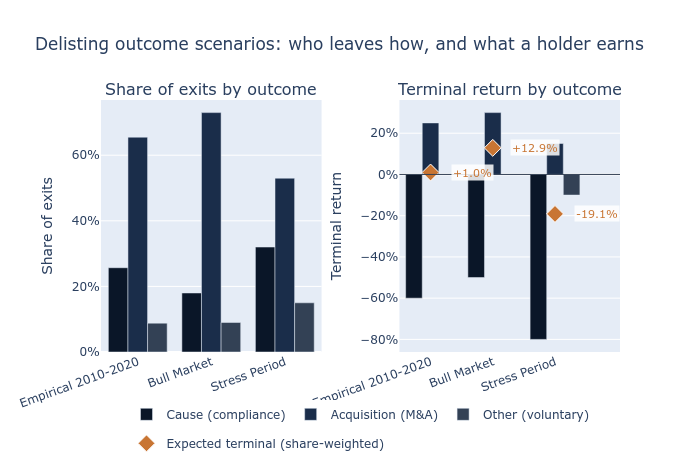

In [14]:
scenario_names = list(SCENARIOS)
bar_colors = [PALETTE["universe"], PALETTE["bull"], PALETTE["stress"]]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Share of exits by outcome", "Terminal return by outcome"),
    horizontal_spacing=0.15,
)
for i, outcome in enumerate(OUTCOMES):
    fig.add_trace(
        go.Bar(
            x=scenario_names,
            y=[SCENARIOS[s][f"{outcome}_share"] for s in scenario_names],
            name=OUTCOME_LABELS[outcome],
            marker_color=bar_colors[i],
            legendgroup=outcome,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=scenario_names,
            y=[SCENARIOS[s][f"{outcome}_return"] for s in scenario_names],
            name=OUTCOME_LABELS[outcome],
            marker_color=bar_colors[i],
            legendgroup=outcome,
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.add_trace(
    go.Scatter(
        x=scenario_names,
        y=[expected_terminal(SCENARIOS[s]) for s in scenario_names],
        mode="markers",
        marker=dict(
            color=PALETTE["survivors"], size=13, symbol="diamond", line=dict(color="white", width=1)
        ),
        name="Expected terminal (share-weighted)",
    ),
    row=1,
    col=2,
)
# Label the diamonds off to the side so the grouped bars never cover them.
for name in scenario_names:
    value = expected_terminal(SCENARIOS[name])
    fig.add_annotation(
        x=name,
        y=value,
        text=f"{value:+.1%}",
        showarrow=False,
        xshift=42,
        font=dict(size=11, color=PALETTE["survivors"]),
        bgcolor="rgba(255,255,255,0.85)",
        row=1,
        col=2,
    )
fig.add_hline(y=0, line_color=PALETTE["rule"], line_width=1, row=1, col=2)
fig.update_yaxes(title_text="Share of exits", tickformat=".0%", row=1, col=1)
fig.update_yaxes(title_text="Terminal return", tickformat=".0%", row=1, col=2)
fig.update_xaxes(tickangle=-20)
fig.update_layout(
    barmode="group",
    height=470,
    title="Delisting outcome scenarios: who leaves how, and what a holder earns",
    legend=dict(orientation="h", yanchor="bottom", y=-0.42, xanchor="center", x=0.5),
)
fig.show()

## 5. The two portfolios

Both are equal-weighted and rebalanced daily, and both use **the same convention** — a
holding is averaged in on every session it is held, contributing zero on a session it is not
quoted. The only difference is who is in them:

- **Biased**: the survivors only. This is what a backtest built from a "current constituents"
  list gets, and it is the wrong answer.
- **Full universe**: every symbol quoted at the start. Leavers are held until their exit
  session, where they are liquidated at `1 + terminal_return`.

`bias = biased − full universe`. **A positive bias means the survivors-only portfolio
overstates.**

In [15]:
window_lifespans = panel.group_by("symbol").agg(pl.col("timestamp").max().alias("last_date"))
exit_threshold = window_end - timedelta(days=15)  # buffer for holiday closures

leavers = window_lifespans.filter(pl.col("last_date").dt.date() < exit_threshold)
survivors = window_lifespans.filter(pl.col("last_date").dt.date() >= exit_threshold)

print(f"Universe at start:   {len(universe):,}")
print(f"Left during window:  {leavers.height:,} ({leavers.height / len(universe):.1%})")
print(f"Survived the window: {survivors.height:,}")

Universe at start:   3,095
Left during window:  752 (24.3%)
Survived the window: 2,343


In [16]:
def build_panel_matrices(returns: pl.DataFrame, drop_suspect: bool) -> dict:
    """Precompute both portfolios' daily returns and the exit schedule.

    `drop_suspect` nulls the returns flagged in §3; the symbol then simply has no return that
    session, exactly as if it had not been quoted.

    The per-session equal-weight return of the *full universe before terminal effects* does not
    depend on the terminal returns, so it is computed once here and reused across every Monte
    Carlo draw. Only the exit-session contribution varies.
    """
    frame = returns
    if drop_suspect:
        frame = frame.with_columns(
            pl.when(pl.col("suspect")).then(None).otherwise(pl.col("ret")).alias("ret")
        )

    wide = frame.pivot(on="symbol", index="timestamp", values="ret").sort("timestamp")
    symbols = [c for c in wide.columns if c != "timestamp"]
    sessions = wide["timestamp"].to_numpy()
    ret = wide.drop("timestamp").to_numpy()  # NaN where the symbol was not quoted

    last = dict(zip(window_lifespans["symbol"], window_lifespans["last_date"], strict=True))
    last_session = np.array([np.datetime64(last[s]) for s in symbols])
    is_survivor = np.isin(symbols, survivors["symbol"].to_numpy())

    alive = sessions[:, None] <= last_session[None, :]  # still in the panel at t
    held = np.vstack([np.ones((1, len(symbols)), bool), alive[:-1]])  # held at close of t-1
    # Only a leaver exits. A survivor whose feed stops a few sessions early is not a delisting.
    exits = (~alive) & held & ~is_survivor[None, :]

    contribution = np.nan_to_num(ret) * held  # unquoted-but-held contributes 0
    n_held_universe = np.maximum(held.sum(1), 1)
    n_held_survivors = np.maximum(held[:, is_survivor].sum(1), 1)

    exit_session, exit_symbol = np.nonzero(exits)  # one pair per leaver

    return {
        "symbols": symbols,
        "sessions": sessions,
        "is_survivor": is_survivor,
        "n_held_universe": n_held_universe,
        # Equal-weight daily return before any terminal effect.
        "base_universe": contribution.sum(1) / n_held_universe,
        "base_survivors": contribution[:, is_survivor].sum(1) / n_held_survivors,
        "exit_session": exit_session,
        "exit_symbol": exit_symbol,
    }


def universe_path(m: dict, terminal: np.ndarray | float) -> np.ndarray:
    """$100-based value path of the full-universe portfolio.

    `terminal` is the return each leaver realises on its exit session — a per-symbol array, or
    a scalar applied to every leaver.
    """
    terminal_by_exit = (
        np.full(m["exit_symbol"].size, terminal)
        if np.isscalar(terminal)
        else np.asarray(terminal)[m["exit_symbol"]]
    )
    daily = m["base_universe"].copy()
    np.add.at(daily, m["exit_session"], terminal_by_exit / m["n_held_universe"][m["exit_session"]])
    return 100.0 * np.cumprod(1 + daily)


def survivor_path(m: dict) -> np.ndarray:
    """$100-based value path of the survivors-only portfolio. No terminal events by definition."""
    return 100.0 * np.cumprod(1 + m["base_survivors"])


def total_return(path: np.ndarray) -> float:
    """Percentage total return of a $100-based value path."""
    return float(path[-1]) - 100.0

### How much does the repair in §3 matter?

Run both portfolios on the raw returns and on the repaired returns, with the terminal return
switched off, so the only moving part is the untrusted rows flagged above.

In [17]:
matrices = {
    "raw": build_panel_matrices(returns, drop_suspect=False),
    "repaired": build_panel_matrices(returns, drop_suspect=True),
}

repair_rows = []
for label, mat in matrices.items():
    biased = total_return(survivor_path(mat))
    full = total_return(universe_path(mat, 0.0))
    repair_rows.append(
        {
            "returns": label,
            "survivors_only_pct": round(biased, 1),
            "full_universe_pct": round(full, 1),
            "bias_pp": round(biased - full, 1),
        }
    )
repair_table = pl.DataFrame(repair_rows)
repair_table

returns,survivors_only_pct,full_universe_pct,bias_pp
str,f64,f64,f64
"""raw""",89.3,102.9,-13.6
"""repaired""",41.7,33.3,8.3


The sign flips. On the raw series the survivors-only portfolio appears to *underperform* the
full universe; on the repaired series it overstates, which is the direction the literature
reports. Roughly 0.03% of the rows decide which way the answer points, because a
daily-rebalanced equal-weight portfolio compounds every one of them and a `$0.05 → $14.20`
reorganisation moves the whole 2,400-name portfolio by double digits in a session.

This is Chapter 2's own lesson turned on Chapter 2's own analysis: the survivorship check
cannot run ahead of the corporate-action check. Everything below uses the repaired series.

In [18]:
m = matrices["repaired"]
leaver_symbols = [s for s, surv in zip(m["symbols"], m["is_survivor"], strict=True) if not surv]
n_leavers = m["exit_symbol"].size

biased_path = survivor_path(m)
biased_return = total_return(biased_path)
print(f"Biased portfolio (survivors only): {biased_return:+.1f}%")
print(f"Leavers with a recorded exit session: {n_leavers:,}")

Biased portfolio (survivors only): +41.7%
Leavers with a recorded exit session: 752


## 6. Quantify the bias

For each scenario, draw an outcome for every leaver from its share vector, assign the
matching terminal return, and compound the full-universe portfolio. Repeat `N_SIMS` times to
get a percentile band on the bias.

The draws are independent across several hundred symbols, so the band will be tight. That
tightness measures **sampling** uncertainty and nothing else. It says nothing about whether
the outcome shares are right — and §6.1 shows that is where the real uncertainty lives.

In [19]:
rng = np.random.default_rng(SEED)


def run_monte_carlo(params: dict, n_sims: int) -> np.ndarray:
    """Bias distribution in percentage points, one draw of leaver outcomes per simulation."""
    shares = [params[f"{o}_share"] for o in OUTCOMES]
    payoffs = np.array([params[f"{o}_return"] for o in OUTCOMES])

    bias = np.empty(n_sims)
    for i in range(n_sims):
        drawn = rng.choice(len(OUTCOMES), size=n_leavers, p=shares)
        # `universe_path` indexes terminal by symbol, so scatter the draw back onto symbols.
        terminal = np.zeros(len(m["symbols"]))
        terminal[m["exit_symbol"]] = payoffs[drawn]
        bias[i] = biased_return - total_return(universe_path(m, terminal))
    return bias


scenario_results = {}
for name, params in SCENARIOS.items():
    bias = run_monte_carlo(params, N_SIMS)
    scenario_results[name] = {
        "bias_median": float(np.median(bias)),
        "bias_p10": float(np.percentile(bias, 10)),
        "bias_p90": float(np.percentile(bias, 90)),
        # Representative path: every leaver assigned the scenario's expected terminal return.
        "path": universe_path(m, expected_terminal(params)),
        "expected_cause": int(n_leavers * params["cause_share"]),
        "expected_acquisition": int(n_leavers * params["acquisition_share"]),
        "expected_other": int(n_leavers * params["other_share"]),
    }

bias_summary = pl.DataFrame(
    [
        {
            "scenario": name,
            "expected_cause": r["expected_cause"],
            "expected_acquisition": r["expected_acquisition"],
            "expected_other": r["expected_other"],
            "bias_median_pp": round(r["bias_median"], 2),
            "bias_p10_pp": round(r["bias_p10"], 2),
            "bias_p90_pp": round(r["bias_p90"], 2),
        }
        for name, r in scenario_results.items()
    ]
)
bias_summary

scenario,expected_cause,expected_acquisition,expected_other,bias_median_pp,bias_p10_pp,bias_p90_pp
str,i64,i64,i64,f64,f64,f64
"""Empirical 2010-2020""",193,492,66,8.0,7.39,8.61
"""Bull Market""",135,548,67,3.47,2.97,4.0
"""Stress Period""",240,398,112,15.27,14.51,15.96


### 6.1 Where the uncertainty actually lives

Two ways to be wrong about the bias. The Monte Carlo prices one of them.

In [20]:
mc_width = np.mean([r["bias_p90"] - r["bias_p10"] for r in scenario_results.values()])
scenario_spread = max(r["bias_median"] for r in scenario_results.values()) - min(
    r["bias_median"] for r in scenario_results.values()
)
no_terminal_bias = biased_return - total_return(universe_path(m, 0.0))

display(
    Markdown(
        f"| Source of uncertainty | Magnitude |\n"
        f"|---|---:|\n"
        f"| Sampling — which leaver draws which outcome ({N_SIMS:,} draws) | {mc_width:.1f} pp |\n"
        f"| Assumption — which scenario's outcome shares are right | {scenario_spread:.1f} pp |\n"
        f"| Data quality — whether §3's repair is applied | "
        f"{abs(repair_table['bias_pp'][0] - repair_table['bias_pp'][1]):.1f} pp |\n\n"
        f"The bias with no terminal return at all is **{no_terminal_bias:+.1f} pp**, against "
        f"**{scenario_results['Empirical 2010-2020']['bias_median']:+.1f} pp** under the empirical "
        f"scenario. The entire Monte Carlo apparatus — three scenarios, {N_SIMS:,} draws each — "
        f"moves the answer by "
        f"**{abs(scenario_results['Empirical 2010-2020']['bias_median'] - no_terminal_bias):.1f} pp**. "
        f"Most of the bias is the *observed* returns of the symbols that left, not the modelled "
        f"returns of what happened to them afterwards. Spend the modelling effort accordingly."
    )
)

| Source of uncertainty | Magnitude |
|---|---:|
| Sampling — which leaver draws which outcome (1,000 draws) | 1.2 pp |
| Assumption — which scenario's outcome shares are right | 11.8 pp |
| Data quality — whether §3's repair is applied | 21.9 pp |

The bias with no terminal return at all is **+8.3 pp**, against **+8.0 pp** under the empirical scenario. The entire Monte Carlo apparatus — three scenarios, 1,000 draws each — moves the answer by **0.4 pp**. Most of the bias is the *observed* returns of the symbols that left, not the modelled returns of what happened to them afterwards. Spend the modelling effort accordingly.

## 7. Summary figure

Left: the two portfolio paths, with the gap between them shaded. Right: the bias under each
scenario, with 10–90% Monte Carlo bands.

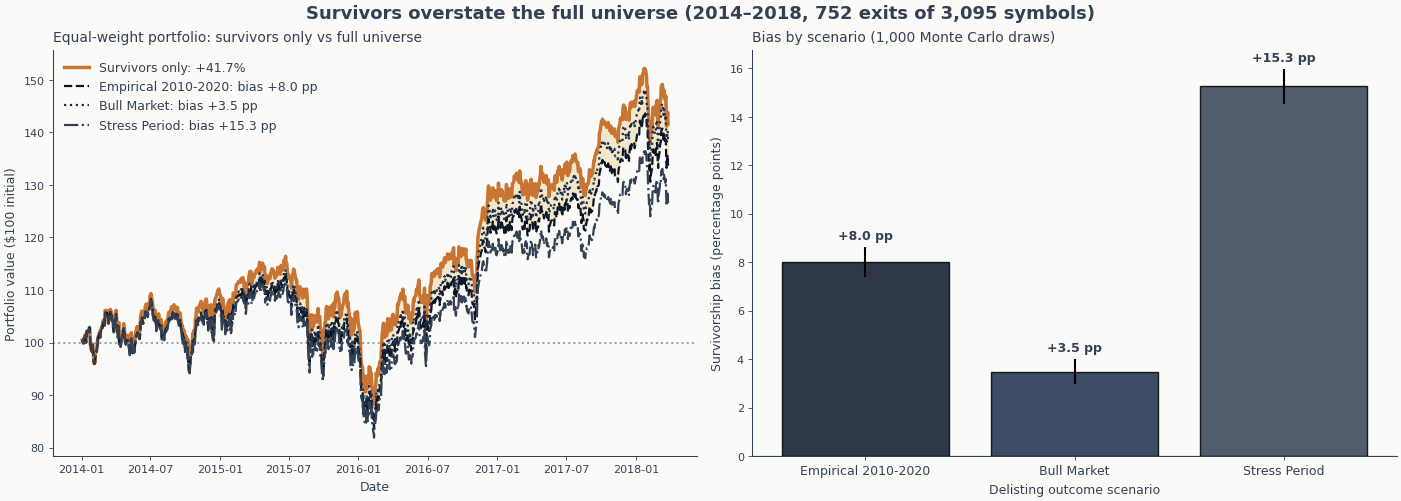

In [21]:
sessions = m["sessions"]
empirical = scenario_results["Empirical 2010-2020"]
# Colour alone does not separate three navy scenarios; pair each with a linestyle.
scenario_colors = {
    "Empirical 2010-2020": PALETTE["universe"],
    "Bull Market": PALETTE["bull"],
    "Stress Period": PALETTE["stress"],
}
scenario_linestyles = {"Empirical 2010-2020": "--", "Bull Market": ":", "Stress Period": "-."}


def plot_paths(ax: plt.Axes) -> None:
    """Left panel: survivors-only against the full universe under each scenario."""
    ax.plot(
        sessions,
        biased_path,
        color=PALETTE["survivors"],
        linewidth=2.5,
        label=f"Survivors only: {biased_return:+.1f}%",
    )
    for name, results in scenario_results.items():
        ax.plot(
            sessions,
            results["path"],
            color=scenario_colors[name],
            linewidth=1.6,
            linestyle=scenario_linestyles[name],
            label=f"{name}: bias {results['bias_median']:+.1f} pp",
        )
    ax.fill_between(sessions, biased_path, empirical["path"], alpha=0.3, color=PALETTE["gap"])
    ax.axhline(100, color=PALETTE["rule"], linestyle=":", alpha=0.5)
    ax.set_xlabel("Date")
    ax.set_ylabel("Portfolio value ($100 initial)")
    ax.set_title("Equal-weight portfolio: survivors only vs full universe")
    ax.legend(loc="upper left", fontsize=9)


def plot_bias(ax: plt.Axes) -> None:
    """Right panel: median bias per scenario with 10-90% whiskers."""
    names = list(scenario_results)
    medians = [scenario_results[s]["bias_median"] for s in names]
    lower = [medians[i] - scenario_results[s]["bias_p10"] for i, s in enumerate(names)]
    upper = [scenario_results[s]["bias_p90"] - medians[i] for i, s in enumerate(names)]
    x = np.arange(len(names))

    ax.bar(
        x,
        medians,
        color=[scenario_colors[s] for s in names],
        alpha=0.85,
        edgecolor="black",
        linewidth=1.0,
    )
    ax.errorbar(
        x, medians, yerr=[lower, upper], fmt="none", color="black", capsize=7, linewidth=1.5
    )
    for i, name in enumerate(names):
        r = scenario_results[name]
        ax.annotate(
            f"{r['bias_median']:+.1f} pp",
            xy=(i, r["bias_p90"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_xlabel("Delisting outcome scenario")
    ax.set_ylabel("Survivorship bias (percentage points)")
    ax.set_title(f"Bias by scenario ({N_SIMS:,} Monte Carlo draws)")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plot_paths(axes[0])
plot_bias(axes[1])
fig.suptitle(
    f"Survivors overstate the full universe ({window_start.year}–{window_end.year}, "
    f"{n_leavers} exits of {len(universe):,} symbols)",
    fontsize=13,
    fontweight="bold",
)
plt.show()

In [22]:
# Persist the figure artifact consumed by the book's figure script (Hard Rule 15).
artifacts_dir = get_chapter_dir(2) / "output" / "book_figure_artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "biased_dates": list(sessions),
    "biased_values": biased_path.tolist(),
    "biased_return": float(biased_return),
    "scenarios": {
        name: {
            "portfolio_timestamps": list(sessions),
            "portfolio_values": r["path"].tolist(),
            "bias_median": r["bias_median"],
            "bias_p10": r["bias_p10"],
            "bias_p90": r["bias_p90"],
        }
        for name, r in scenario_results.items()
    },
    "metadata": {
        "n_sims": int(N_SIMS),
        "start_year": int(window_start.year),
        "end_year": int(window_end.year),
        "n_stocks_at_start": int(len(universe)),
        "n_delisted": int(n_leavers),
        "delisted_pct": float(n_leavers / len(universe) * 100),
        "seed": int(SEED),
        "untrusted_returns_dropped": int(n_suspect),
        "phantom_sessions_dropped": int(phantom.height),
    },
}
with open(artifacts_dir / "figure_2_2_survivorship_bias.pkl", "wb") as f:
    pickle.dump(payload, f)
print(
    f"Persisted figure_2_2_survivorship_bias.pkl ({len(sessions)} sessions, {len(payload['scenarios'])} scenarios)"
)

Persisted figure_2_2_survivorship_bias.pkl (1064 sessions, 3 scenarios)


## 8. What happened to the symbols that left?

The scenarios in §4 model what holders received *after* the last quote. This section looks at
the part the panel does observe: how the leavers performed *while* they were still quoted.

In [23]:
# A symbol whose returns were all untrusted has an uninterpretable first/last price ratio.
suspect_symbols = returns.filter(pl.col("suspect"))["symbol"].unique().to_list()

leaver_stats = (
    panel.filter(pl.col("symbol").is_in(leaver_symbols))
    .sort(["symbol", "timestamp"])
    .group_by("symbol")
    .agg(
        [
            pl.col("adj_close").first().alias("first_price"),
            pl.col("adj_close").last().alias("last_price"),
            pl.len().alias("sessions"),
        ]
    )
    .with_columns(((pl.col("last_price") / pl.col("first_price") - 1) * 100).alias("total_return"))
    .filter(~pl.col("symbol").is_in(suspect_symbols))
)

survivor_stats = (
    panel.filter(pl.col("symbol").is_in(survivors["symbol"].to_list()))
    .sort(["symbol", "timestamp"])
    .group_by("symbol")
    .agg(
        [
            pl.col("adj_close").first().alias("first_price"),
            pl.col("adj_close").last().alias("last_price"),
        ]
    )
    .with_columns(((pl.col("last_price") / pl.col("first_price") - 1) * 100).alias("total_return"))
    .filter(~pl.col("symbol").is_in(suspect_symbols))
)

print(
    f"Leavers   (n={leaver_stats.height}): mean {leaver_stats['total_return'].mean():+.1f}%, "
    f"median {leaver_stats['total_return'].median():+.1f}%, "
    f"negative {leaver_stats.filter(pl.col('total_return') < 0).height / leaver_stats.height:.0%}"
)
print(
    f"Survivors (n={survivor_stats.height}): mean {survivor_stats['total_return'].mean():+.1f}%, "
    f"median {survivor_stats['total_return'].median():+.1f}%, "
    f"negative {survivor_stats.filter(pl.col('total_return') < 0).height / survivor_stats.height:.0%}"
)

Leavers   (n=702): mean +13.9%, median +13.5%, negative 40%
Survivors (n=2257): mean +42.2%, median +30.8%, negative 33%


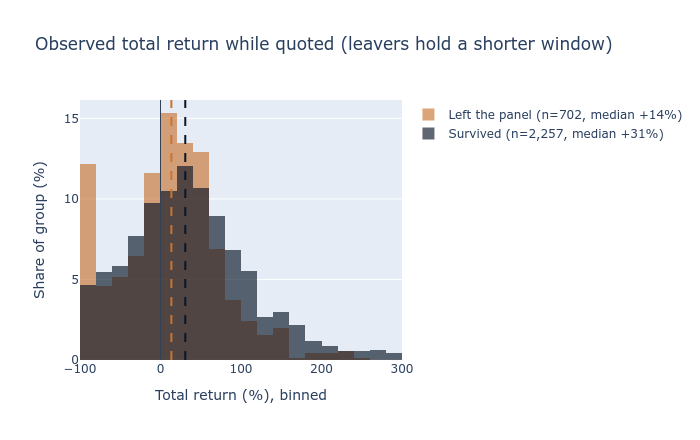

In [24]:
# The two groups differ in size by 3x, so plot the share of each group per bin, not counts.
bins = dict(start=-100, end=300, size=20)

fig = go.Figure()
for stats, label, color in [
    (leaver_stats, "Left the panel", PALETTE["survivors"]),
    (survivor_stats, "Survived", PALETTE["universe"]),
]:
    fig.add_trace(
        go.Histogram(
            x=stats["total_return"].to_list(),
            xbins=bins,
            histnorm="percent",
            name=f"{label} (n={stats.height:,}, median {stats['total_return'].median():+.0f}%)",
            marker_color=color,
            opacity=0.65,
        )
    )
    # Median in the legend, not as an annotation — the two medians are 17pp apart and collide.
    fig.add_vline(x=stats["total_return"].median(), line_dash="dash", line_color=color)
fig.add_vline(x=0, line_color=PALETTE["rule"], line_width=1)
fig.update_layout(
    title="Observed total return while quoted (leavers hold a shorter window)",
    xaxis_title="Total return (%), binned",
    yaxis_title="Share of group (%)",
    xaxis=dict(range=[-100, 300]),
    barmode="overlay",
    height=440,
)
fig.show()

Leavers hold their shorter window and, over it, underperform the survivors. That is the
mechanism behind the positive bias in §6: dropping them from the universe removes the weaker
half of the distribution. The terminal-return scenarios then adjust the estimate at the
margin — they do not create it.

## 9. Detecting bias in your own data

Two cheap tests. The first catches a universe filtered to today's constituents; the second
catches the pattern this panel shows, where exits are recorded but only for part of the history.

In [25]:
def check_survivorship_bias(data: pl.DataFrame, symbol_col: str, date_col: str) -> dict:
    """Flag the two signatures of a survivorship-filtered universe."""
    lifespans = data.group_by(symbol_col).agg(
        [pl.col(date_col).min().alias("first_date"), pl.col(date_col).max().alias("last_date")]
    )

    # Signature 1: nearly every symbol ends on the same date — nothing ever left.
    end_dates = lifespans["last_date"].n_unique()
    all_same_end = end_dates < 10

    # Signature 2: a delisting rate too low to be a real universe.
    latest_date = lifespans["last_date"].max()
    early_ends = lifespans.filter(pl.col("last_date") < latest_date).height
    delisting_rate = early_ends / lifespans.height

    # Signature 3: exits recorded over only part of the panel's span.
    exit_years = lifespans.filter(pl.col("last_date") < latest_date)["last_date"].dt.year()
    span_years = latest_date.year - lifespans["first_date"].min().year + 1
    exit_span_years = (exit_years.max() - exit_years.min() + 1) if len(exit_years) else 0

    return {
        "total_symbols": lifespans.height,
        "unique_end_dates": end_dates,
        "all_same_end_date": all_same_end,
        "early_ending_symbols": early_ends,
        "delisting_rate": delisting_rate,
        "panel_span_years": span_years,
        "exit_span_years": exit_span_years,
        "exits_cover_full_span": exit_span_years >= 0.8 * span_years,
        "likely_biased": all_same_end
        or delisting_rate < 0.05
        or exit_span_years < 0.8 * span_years,
    }


bias_check = check_survivorship_bias(wiki, "symbol", "timestamp")
bias_check

{'total_symbols': 3199,
 'unique_end_dates': 497,
 'all_same_end_date': False,
 'early_ending_symbols': 777,
 'delisting_rate': 0.24288840262582057,
 'panel_span_years': 57,
 'exit_span_years': 5,
 'exits_cover_full_span': False,
 'likely_biased': True}

The panel passes the first two tests — 24% of symbols leave, on many distinct dates — and
fails the third. A delisting rate alone is not evidence of a survivorship-aware panel. **Ask
when the delistings happened.**

## 10. Universe completeness

Survivorship asks whether exits are recorded. Completeness asks the mirror question: are
**entries** recorded? A panel can carry every delisting and still miss every IPO.

In [26]:
def check_universe_completeness(
    data: pl.DataFrame,
    symbol_col: str,
    date_col: str,
    expected_market_size: int = 4500,
    expected_ipo_rate: tuple[int, int] = (100, 400),
) -> dict:
    """Annual entry/exit flows plus coverage warnings."""
    lifespans = (
        data.group_by(symbol_col)
        .agg(
            [pl.col(date_col).min().alias("first_date"), pl.col(date_col).max().alias("last_date")]
        )
        .with_columns(
            [
                pl.col("first_date").dt.year().alias("first_year"),
                pl.col("last_date").dt.year().alias("last_year"),
            ]
        )
    )
    min_year, max_year = lifespans["first_year"].min(), lifespans["last_year"].max()

    new_by_year = (
        lifespans.group_by("first_year")
        .agg(pl.len().alias("new_listings"))
        .rename({"first_year": "year"})
    )
    exits_by_year = (
        lifespans.filter(pl.col("last_year") < max_year)
        .group_by("last_year")
        .agg(pl.len().alias("delistings"))
        .rename({"last_year": "year"})
    )
    annual_flows = (
        pl.DataFrame({"year": list(range(min_year, max_year + 1))})
        .join(new_by_year, on="year", how="left")
        .join(exits_by_year, on="year", how="left")
        .with_columns(
            [
                pl.col("new_listings").fill_null(0).cast(pl.Int64),
                pl.col("delistings").fill_null(0).cast(pl.Int64),
            ]
        )
        .with_columns((pl.col("new_listings") - pl.col("delistings")).alias("net_change"))
        .sort("year")
    )

    total_symbols = lifespans.height
    middle = annual_flows.filter((pl.col("year") > min_year) & (pl.col("year") < max_year))
    recent_new = annual_flows.filter(pl.col("year") >= max_year - 2)["new_listings"].sum()
    years_with_zero_new = annual_flows.filter(pl.col("new_listings") == 0).height
    coverage_ratio = total_symbols / expected_market_size

    warnings = []
    if recent_new < 50:
        warnings.append(f"Coverage frozen: only {recent_new} new listings in the final 3 years")
    if len(middle) and middle["new_listings"].mean() < expected_ipo_rate[0]:
        warnings.append(
            f"Avg new listings ({middle['new_listings'].mean():.0f}/yr) below the expected "
            f"{expected_ipo_rate[0]}-{expected_ipo_rate[1]} range"
        )
    if coverage_ratio < 0.9:
        warnings.append(
            f"Coverage ratio {coverage_ratio:.0%} — the panel is a subset of the market"
        )

    return {
        "annual_flows": annual_flows,
        "total_symbols": total_symbols,
        "expected_market_size": expected_market_size,
        "coverage_ratio": coverage_ratio,
        "years_with_zero_new": years_with_zero_new,
        "avg_new_listings": middle["new_listings"].mean() if len(middle) else 0,
        "avg_delistings": middle["delistings"].mean() if len(middle) else 0,
        "warnings": warnings,
    }

For context, the US listed-company count peaked near 8,090 in 1996 (World Bank) and has run
4,000–5,000 since 2010. A panel of ~3,200 symbols is a subset, not the market.

In [27]:
completeness = check_universe_completeness(wiki, symbol_col="symbol", date_col="timestamp")

print(
    f"{completeness['total_symbols']:,} symbols vs ~{completeness['expected_market_size']:,} expected "
    f"({completeness['coverage_ratio']:.1%} coverage)"
)
print(
    f"Middle-of-panel flows: {completeness['avg_new_listings']:.0f} new listings/yr, "
    f"{completeness['avg_delistings']:.0f} delistings/yr"
)
for w in completeness["warnings"]:
    print(f"  WARNING: {w}")

3,199 symbols vs ~4,500 expected (71.1% coverage)
Middle-of-panel flows: 58 new listings/yr, 13 delistings/yr


### Interpretation

Both flows fail, and they fail at opposite ends of the panel:

1. **Exits are missing before ~2014** — the panel was backfilled from a snapshot of
   then-living symbols (§1).
2. **Entries dry up after ~2014** — contributors stopped adding IPOs, and the feed stopped
   entirely in March 2018.
3. **The panel is a subset** — ~3,200 symbols against a 4,000–5,000 name market, skewed
   toward liquid names.

Bias-free is not the same as complete, and this panel is neither over its full span. It *is*
usable for survivorship work over 2014–2018, which is what §6 measures. For anything longer,
use a panel with an explicit universe definition and delisting returns: CRSP, Compustat, or a
commercial vendor.

## Key takeaways

**What it does.** Measures how much an equal-weight portfolio of survivors overstates the
same portfolio built on the full starting universe, over the only window in which the US
equities panel records exits.

**What it finds.**

1. **The panel records exits only from 2014.** All 777 exits in a 1962–2018 panel fall in
   2014–2018. Firms exited before then; the collection process did not capture it. Absence of
   evidence, not evidence of absence — and no way to recover what is missing.
2. **The adjusted prices carry unadjusted corporate actions.** Reverse splits and
   post-bankruptcy reorganisations on reused tickers produce single-session price jumps that
   are not returns — HERO `$0.05 → $14.20`, PCO `$6.97 → $660.00` (a 1-for-100 reverse split),
   EXXI `$0.13 → $32.50` — every one of them with `split_ratio = 1.0`. They are ~0.03% of rows.
3. **Those rows decide the sign of the answer.** Uncorrected, the survivors-only portfolio
   appears to *underperform* the full universe. Repaired, it overstates — the direction the
   literature reports. The survivorship check cannot run ahead of the corporate-action check.
4. **The terminal-return model is the least consequential part of the estimate.** Setting
   every terminal return to zero moves the empirical-scenario bias by well under a point. The
   bias comes from the *observed* returns of the symbols that left, not from what they paid
   out afterwards. Assumption risk (which scenario) exceeds sampling risk (the Monte Carlo
   band) by an order of magnitude.
5. **Bias-free is not complete.** The panel adds almost no new listings after 2014 and covers
   ~71% of the US market. A dataset can record every delisting and still miss every IPO.

**What it means.** Survivorship bias is not a fact you look up; it is an estimate you build,
and it inherits every defect of the data underneath it. The direction of the bias depends on
the delisting mix, its magnitude on the leavers' observed returns, and its *sign*, here, on
whether anyone checked the corporate actions first. Applying a 0% terminal value to delisted
symbols is not bias-free; it is merely unrealistic.

**Next**: `16_provider_comparison` moves from one panel's internal bias to stitching several
providers together, where universe and coverage definitions diverge. **Book reference**: §2.3.